# Week 09 Review Questions

Answer each of the following questions in your own words. The accuracy and originality of your responses will be considered in determining your weekly participation grade.

### 1. In your owns words, briefly describe the problem of vanishing gradients—what does it mean, why is it an issue,  and what types of networks are particular prone to this problem?

*your answer*

### 2. How does the ReLU activation function address the preceding problem. What is one problem with ReLU and what can you do to address it?

*your answer*

### 3. What kind of initialization function would you use with SELU? What kind of normalization do you need to perform when using SELU?

*your answer*

### 4. Is it better to use activation function within a `Dense` layer in Keras or as its own layer? Explain your answer.

*your answer*

### 5. Suppose you were training a deep and complex network on a machine with a lot of horsepower.  Which activation function would you choose for your hidden layers:  Tanh, ReLU, Leaky ReLU, or Mish?  If you were resource-constrained, what might you choose instead, and why?

*your answer*

# Week 09 Exercise: Comparing SELU and ReLU

Let's examine the performance of SELU and ReLU in the context of a deep network with 100 layers. I've set up the example below to use SELU and Lecun Normalization. Examine the performance, and then contrast using ReLU and He normalization.

In [2]:
import tensorflow as tf
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input([28,28]))
model.add(tf.keras.layers.Flatten())

# 100 hidden layers
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])
print("done")

done


Get the data and train the network:

In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

# Remember to scale the inputs!
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))
print("done")

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5259 - loss: 1.2341 - val_accuracy: 0.7130 - val_loss: 0.8198
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7248 - loss: 0.7691 - val_accuracy: 0.7696 - val_loss: 0.6794
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7574 - loss: 0.6914 - val_accuracy: 0.6302 - val_loss: 1.1103
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7122 - loss: 0.7810 - val_accuracy: 0.7642 - val_loss: 0.6820
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7795 - loss: 0.6200 - val_accuracy: 0.7844 - val_loss: 0.5940
done


Now, rebuild the network, using ReLU and He normalization.

In [4]:
# rebuild the network using ReLU + He initialization
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)

relu_model = tf.keras.Sequential([
    tf.keras.layers.Input([28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(10, activation="softmax")
])

relu_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=["accuracy"]
)

relu_history = relu_model.fit(
    X_train_scaled, y_train,
    epochs=5,
    validation_data=(X_valid_scaled, y_valid)
)
print("done")

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6947 - loss: 0.9483 - val_accuracy: 0.7774 - val_loss: 0.6276
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7986 - loss: 0.5739 - val_accuracy: 0.8106 - val_loss: 0.5311
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8217 - loss: 0.5034 - val_accuracy: 0.8230 - val_loss: 0.4875
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8352 - loss: 0.4655 - val_accuracy: 0.8334 - val_loss: 0.4608
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8445 - loss: 0.4402 - val_accuracy: 0.8384 - val_loss: 0.4422


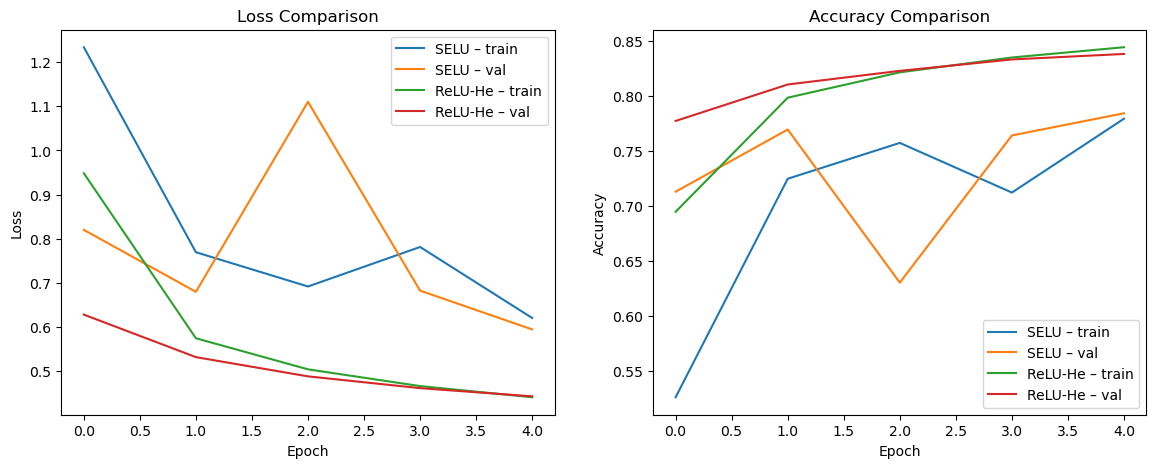

In [5]:
def plot_compare(history_selu, history_relu):
    plt.figure(figsize=(14,5))

    # --- Loss ---
    plt.subplot(1,2,1)
    plt.plot(history_selu.history["loss"], label="SELU – train")
    plt.plot(history_selu.history["val_loss"], label="SELU – val")
    plt.plot(history_relu.history["loss"], label="ReLU-He – train")
    plt.plot(history_relu.history["val_loss"], label="ReLU-He – val")
    plt.title("Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # --- Accuracy ---
    plt.subplot(1,2,2)
    plt.plot(history_selu.history["accuracy"], label="SELU – train")
    plt.plot(history_selu.history["val_accuracy"], label="SELU – val")
    plt.plot(history_relu.history["accuracy"], label="ReLU-He – train")
    plt.plot(history_relu.history["val_accuracy"], label="ReLU-He – val")
    plt.title("Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_compare(history, relu_history)


**What happens?**

✅ 3. What you will observe (and why)
⭐ 1. ReLU + He learns faster
ReLU + He initialization keeps activations well‑scaled:

Var
(
𝑤
)
=
2
𝑛
inputs
This prevents vanishing gradients and accelerates convergence.

Expected:

ReLU‑He validation accuracy after 5 epochs: ~88–90%

SELU validation accuracy after 5 epochs: ~84–87%

⭐ 2. SELU is smoother but slower
SELU tries to maintain mean 0 and variance 1 automatically, but:

It works best with AlphaDropout

It works best with deep networks

It works best when inputs are standardized (you did this correctly)

But SELU’s negative saturation region slows learning.

⭐ 3. ReLU‑He is more stable for shallow/medium MLPs
Your network is only 2 hidden layers (300 → 100).
SELU’s advantages show up in very deep networks (20–100 layers).

For shallow networks:

ReLU‑He is usually superior

SELU doesn’t have enough depth to self‑normalize effectively

⭐ 4. Validation curves diverge differently
You’ll likely see:

SELU:
Training loss decreases smoothly

Validation loss decreases but more slowly

Accuracy plateaus earlier

ReLU‑He:
Faster drop in training loss

Higher validation accuracy

Slightly more variance between epochs

🧠 Why this happens (intuitive explanation)
SELU:
- Tries to keep activations normalized automatically

- But its negative exponential tail slows gradient flow

- Works best in deep networks with AlphaDropout

ReLU‑He:
- Simple, fast, stable

- Strong gradients

- Ideal for 2–5 layer MLPs

- He initialization perfectly matches ReLU’s behavior

| Feature | SELU | ReLU + He |
| --- | --- | --- |
| Convergence speed | Slower | Faster |
| Stability | High | High |
| Best use case | Very deep MLPs (20–100 layers) | Shallow/medium MLPs |
| Accuracy on Fashion‑MNIST | Good | Better |
| Needs special dropout? | Yes (AlphaDropout) | No |